Online Retail Purchase Pattern

Dahiyah

In [24]:
import warnings
import os

# Suppress Python warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore')

# Suppress system/environment warnings (like the jupyter_client one)
os.environ['PYTHONWARNINGS'] = 'ignore'

In [25]:
pip install apyori

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [27]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/online_retail_II.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# ------------------------------
# 4.1 DATATSET OVERVIEW
#-------------------------------

# drop columns 'Invoice', 'StockCode', 'Quantity', 'Price' and 'Country'
data = data.drop(columns=['Invoice', 'StockCode', 'Quantity', 'Price', 'Country'])

# display basic dataset info
print("\nBasic Information of the Dataset:")
data.info()

# checking for missing values
print("\nChecking for Missing Values")
print(data.isnull().sum())

# checking for duplicate records
duplicates = data.duplicated().sum()
print(f"\nNumber of Duplicate Records: {duplicates}")

# descriptive statistics to understand item frequencies and transaction distribution
print("\nDescriptive Statistics")
print(data.describe(include='all'))

# display the first few rows
data.head()

# unique items in transactions
print("\nNUmber of Unique Items:", data['Description'].nunique())
print("Number of Unique Transactions:", data['Customer ID'].nunique())


Basic Information of the Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Description  1062989 non-null  object 
 1   InvoiceDate  1067371 non-null  object 
 2   Customer ID  824364 non-null   float64
dtypes: float64(1), object(2)
memory usage: 24.4+ MB

Checking for Missing Values
Description      4382
InvoiceDate         0
Customer ID    243007
dtype: int64

Number of Duplicate Records: 49816

Descriptive Statistics
                               Description          InvoiceDate    Customer ID
count                              1062989              1067371  824364.000000
unique                                5698                47635            NaN
top     WHITE HANGING HEART T-LIGHT HOLDER  2010-12-06 16:57:00            NaN
freq                                  5918                 1350            NaN
mean             

In [29]:
# ------------------------------
# 4.2 DATATSET PREPROCESSING
#-------------------------------

# renaming columns for consistency and ease of use
data.rename(columns={'Customer ID': 'Transaction', 'Description': 'Item', 'Invoice': 'Date'}, inplace=True)

# handling missing values
data = data.dropna()
print(f"\nAfter dropping missing values, shape of data: {data.shape}")

# handling duplicates
data = data.drop_duplicates()
print(f"\nAfter dropping duplicates, shape of data: {data.shape}")

# removing duplicate rows
data = data.drop_duplicates()
print(f"\nAfter dropping duplicates, shape of data: {data.shape}")

# ----------
# Define suspicious keywords (lowercase)
keywords_to_remove = ['adjustment', 'bank', 'carriage', 'check', 'commission', 'postage', 'manual', 'test', 'dotcom']

# Filter out rows that contain any of the keywords (case-insensitive search)
pattern = '|'.join(keywords_to_remove)
data = data[~data['Item'].str.lower().str.contains(pattern, na=False)]

# Confirm filtering
print("\nRemoved rows containing non-giftware keywords.")
print("Remaining unique descriptions:", data['Item'].nunique())
# ----------
# standardising the Item column for consistency
data['Item'] = data['Item'].astype(str).str.strip().str.lower().astype('category')
data['Transaction']= data['Transaction'].astype(int)

# transforming data into transaction format for the apriori algorithm
transactions = data.groupby('Transaction')['Item'].apply(list).tolist()

# display a sample of preprocessed transaction
print("\nSample Preprocessed Transactions:")
print(transactions[:5])


After dropping missing values, shape of data: (824364, 3)

After dropping duplicates, shape of data: (786694, 3)

After dropping duplicates, shape of data: (786694, 3)

Removed rows containing non-giftware keywords.
Remaining unique descriptions: 5263

Sample Preprocessed Transactions:
[['red spotty childs umbrella', 'edwardian parasol red', 'edwardian parasol natural', 'edwardian parasol black', 'edwardian parasol pink', 'doormat spotty home sweet home', 'doormat welcome to our home', 'doormat i love london', 'doormat christmas village', 'doormat black flock', 'doormat welcome sunrise', 'doormat 3 smiley cats', 'doormat home sweet home blue', 'doormat fancy font home sweet home', 'doormat union flag', 'doormat merry christmas red', 'doormat respectable house', 'doormat fairy cake', 'doormat peace on earth blue', 'doormat welcome puppies', 'doormat new england', 'doormat airmail', 'doormat red spot', 'doormat union jack guns and roses', 'discount', 'medium ceramic top storage jar', 'm

In [30]:
# --------------------------------------------------------
# 4.3 FREQUENT ITEMSETS GENERATION WITH APRIORI ALGORITHM
#---------------------------------------------------------

# Transforming transactions to a one-hot encoded DataFrame
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
data_trans = pd.DataFrame(te_ary, columns=te.columns_)

# display the one-hot encoded data
print('\nOne-Hot Encoded Data:')
print(data_trans.head())

# Sample 50% of the data to reduce memory usage (colab keeps crashing due to large dataset)
sampled_data = data_trans.sample(frac=0.5, random_state=42)

# Apply Apriori on the sampled data (not full data)
frequent_itemsets = apriori(sampled_data, min_support=0.05, use_colnames=True)
frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(len)

# sort frequent itemsets by support and length
frequent_itemsets.sort_values(by=['support', 'itemset_length'], ascending=[False, False], inplace = True)

# display top 10 frequent itemsets by support
print("\nTop` 10 Frequent Itemsets by Support:")
print(frequent_itemsets.head(10))


One-Hot Encoded Data:
   10 colour spaceboy pen  11 pc ceramic tea set polkadot  \
0                   False                           False   
1                    True                           False   
2                   False                           False   
3                   False                           False   
4                   False                           False   

   12 ass zinc christmas decorations  12 coloured party balloons  \
0                              False                       False   
1                              False                       False   
2                              False                       False   
3                              False                       False   
4                              False                       False   

   12 daisy pegs in wood box  12 egg house painted wood  \
0                      False                      False   
1                      False                      False   
2                      F

In [31]:
# --------------------------------------------------------
# 4.4 ASSOCIATION RULES BASED ON THE FREQUENT ITEMSETS
#---------------------------------------------------------

# generating association rules within minimum confidence and lift threshold
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)
rules = rules[(rules['lift'] > 1.2) & (rules['confidence'] >= 0.4)]

# sorting rules
rules.sort_values(by=['confidence', 'lift'], ascending=[False, False], inplace = True)

# display top 10 rules
print("\nTop 10 Association Rules by Confidence and Lift")
print(rules.head(10))


Top 10 Association Rules by Confidence and Lift
                                           antecedents  \
182                  (candleholder pink hanging heart)   
138                   (pink regency teacup and saucer)   
163                        (poppy's playhouse bedroom)   
242                   (pink regency teacup and saucer)   
221  (regency cakestand 3 tier, green regency teacu...   
1                   (red hanging heart t-light holder)   
180                                (toilet metal sign)   
222  (green regency teacup and saucer, roses regenc...   
72                   (green regency teacup and saucer)   
162                        (poppy's playhouse kitchen)   

                              consequents  antecedent support  \
182  (white hanging heart t-light holder)            0.057862   
138     (green regency teacup and saucer)            0.060585   
163           (poppy's playhouse kitchen)            0.063649   
242     (roses regency teacup and saucer)           

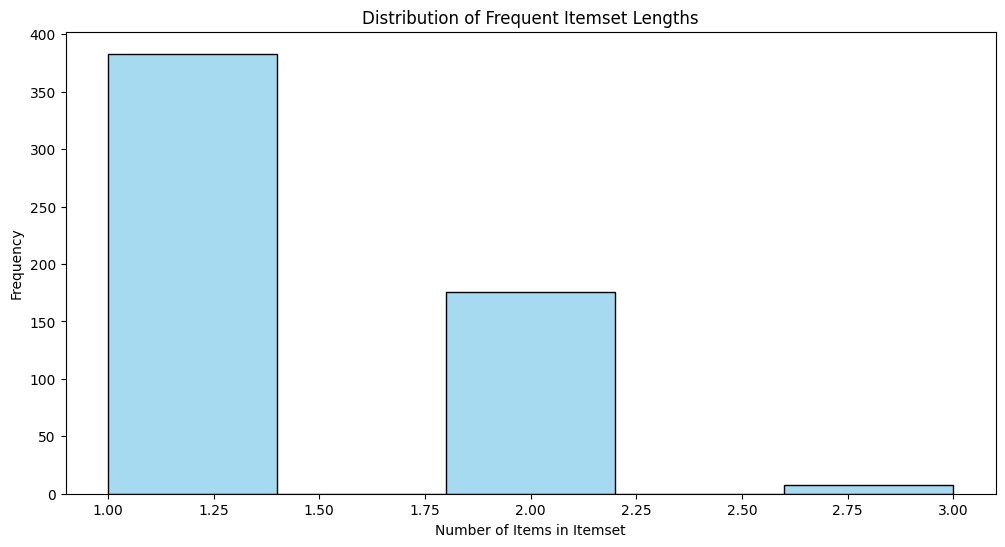

In [32]:
# --------------------------------------------------------
# 5.1 VISUALISING FREQUENT ITEMSETS
#---------------------------------------------------------

# distribution of itemset lengths
plt.figure(figsize=(12, 6))
sns.histplot(frequent_itemsets['itemset_length'], bins=5, color="skyblue")
plt.title('Distribution of Frequent Itemset Lengths')
plt.xlabel('Number of Items in Itemset')
plt.ylabel('Frequency')
plt.show()

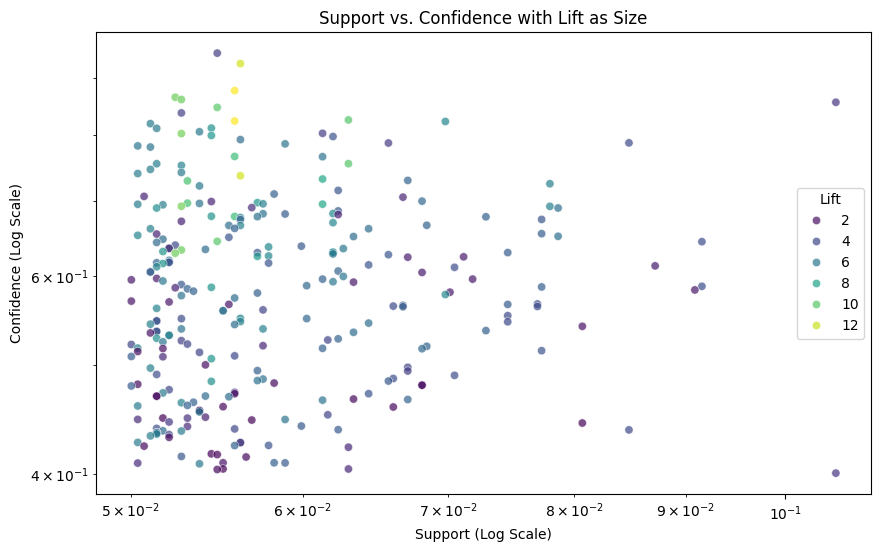

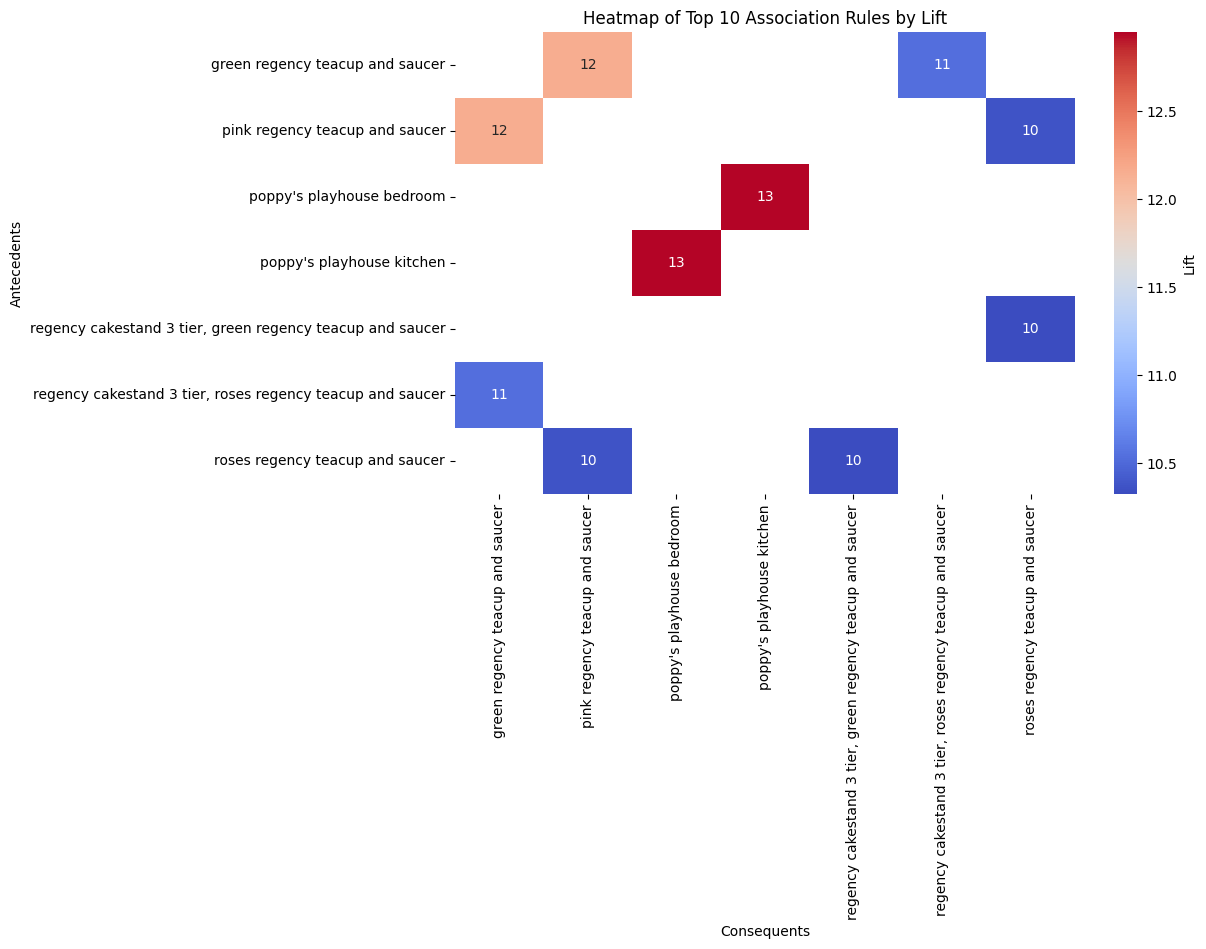

In [33]:
# --------------------------------------------------------
# 5.1 VISUALISING ASSOCIATION RULES
#---------------------------------------------------------

# visualising the relationship between support, confidence and lift
plt.figure(figsize=(10,6))
sns.scatterplot(data=rules, x='support', y='confidence', hue='lift', palette='viridis', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.title('Support vs. Confidence with Lift as Size')
plt.xlabel('Support (Log Scale)')
plt.ylabel('Confidence (Log Scale)')
plt.legend(title='Lift')
plt.show()

# heatmap of top 10 association rules by lift for antecedent consequent pairs
top_rules_lift = rules.nlargest(10, 'lift')
top_rules_lift['antecedents'] = top_rules_lift['antecedents'].apply(lambda x: ', '.join(list(x)))
top_rules_lift['consequents'] = top_rules_lift['consequents'].apply(lambda x: ', '.join(list(x)))

pivot = top_rules_lift.pivot_table(index='antecedents', columns='consequents', values='lift')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, cmap='coolwarm', cbar_kws={'label': 'Lift'})
plt.title('Heatmap of Top 10 Association Rules by Lift')
plt.xlabel('Consequents')
plt.ylabel('Antecedents')
plt.show()